In [9]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

In [15]:
df = pd.read_csv('../../data/csv/BMI.csv')
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)
df

['NCD_BMI_18A', 'NCD_BMI_18C', 'NCD_BMI_25A', 'NCD_BMI_25C', 'NCD_BMI_30A', 'NCD_BMI_30C', 'NCD_BMI_MEAN', 'NCD_BMI_MEANC', 'NCD_BMI_MINUS2C', 'NCD_BMI_PLUS1C', 'NCD_BMI_PLUS2C']


,Unnamed: 0,ParentLocationCode,SpatialDim,Value,NumericValue,TimeDimensionBegin,TimeDimensionEnd,TimeDimensionValue,TimeDimType,TimeDim,IndicatorCode
0,0,AFR,GHA,8.5 [7.4-9.5],8.456378,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012,YEAR,2012,NCD_BMI_18A
1,1,AMR,ECU,1.6 [1.3-2.0],1.631755,2013-01-01T00:00:00+01:00,2013-12-31T00:00:00+01:00,2013,YEAR,2013,NCD_BMI_18A
2,2,AMR,CRI,3.2 [2.2-4.5],3.172688,2003-01-01T00:00:00+01:00,2003-12-31T00:00:00+01:00,2003,YEAR,2003,NCD_BMI_18A
3,3,AFR,GIN,10.1 [6.6-14.4],10.132378,2022-01-01T00:00:00+01:00,2022-12-31T00:00:00+01:00,2022,YEAR,2022,NCD_BMI_18A
4,4,EMR,SAU,3.9 [3.1-4.9],3.914519,2014-01-01T00:00:00+01:00,2014-12-31T00:00:00+01:00,2014,YEAR,2014,NCD_BMI_18A
...,...,...,...,...,...,...,...,...,...,...,...
453072,453072,EUR,BEL,5.1 [3.4-7.0],5.051485,1997-01-01T00:00:00+01:00,1997-12-31T00:00:00+01:00,1997,YEAR,1997,NCD_BMI_PLUS2C
453073,453073,EMR,SDN,1.7 [0.7-3.4],1.715090,2006-01-01T00:00:00+01:00,2006-12-31T00:00:00+01:00,2006,YEAR,2006,NCD_BMI_PLUS2C
453074,453074,AFR,CPV,1.8 [0.4-5.0],1.842421,2000-01-01T00:00:00+01:00,2000-12-31T00:00:00+01:00,2000,YEAR,2000,NCD_BMI_PLUS2C
453075,453075,AFR,STP,4.7 [0.9-12.3],4.681022,2005-01-01T00:00:00+01:00,2005-12-31T00:00:00+01:00,2005,YEAR,2005,NCD_BMI_PLUS2C


In [16]:
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

453077
449717
0


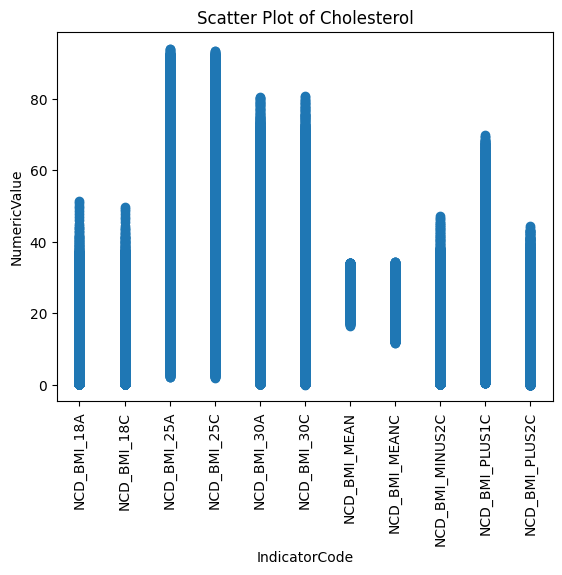

In [17]:
plt.figure()
plt.scatter(df['IndicatorCode'], df['NumericValue'])
plt.xlabel('IndicatorCode')
plt.ylabel('NumericValue')
plt.title('Scatter Plot of Cholesterol')
plt.xticks(rotation=90)
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_8360\1515023557.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=codes)


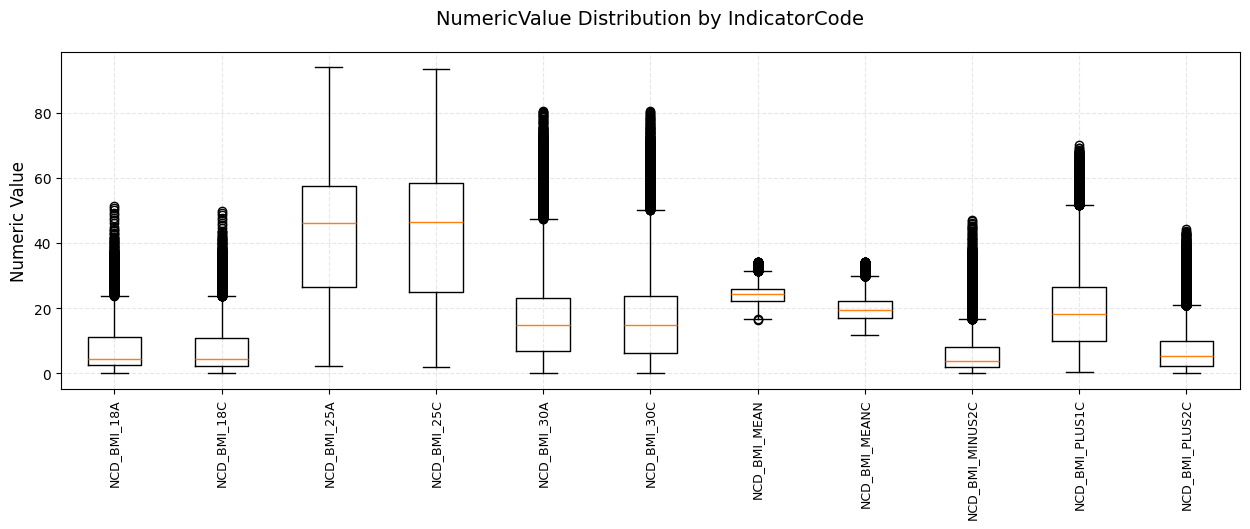

In [19]:
plt.figure(figsize=(14, 6))

codes = df['IndicatorCode'].unique()
data = [df[df['IndicatorCode'] == c]['NumericValue'] for c in codes]

plt.boxplot(data, labels=codes)
plt.xticks(rotation=90, fontsize=9)  # Xoay 90 độ và giảm font
plt.title('NumericValue Distribution by IndicatorCode', fontsize=14, pad=20)
plt.ylabel('Numeric Value', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Điều chỉnh layout để nhãn không bị cắt
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()

In [20]:
# ==============================
# 1. KIỂM TRA & CHUẨN HÓA (Đã sửa lỗi Mixed Timezones)
# ==============================
df1 = df[df['IndicatorCode'] == 'NCD_CHOL_MEANNONHDL_A']
df1["NumericValue"] = pd.to_numeric(df1["NumericValue"], errors="coerce")

# Thêm utc=True để xử lý các múi giờ khác nhau
df1["Date"] = pd.to_datetime(df1["Date"], errors="coerce", utc=True)

# ==============================
# 2. GỘP DỮ LIỆU & TÍNH LOG
# ==============================
df_grouped = (
    df1.groupby(
        ["SpatialDim", "ParentLocationCode"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count")
    )
)

# Tạo cột LogMeanValue: log1p(x) = log(1 + x)
# Việc cộng 1 giúp tránh lỗi nếu MeanValue bằng 0
df_grouped["LogMeanValue"] = np.log1p(df_grouped["MeanValue"])

# ==============================
# 3. LOAD BẢN ĐỒ & MERGE
# ==============================
world = gpd.read_file("../../../worldmap/ne_110m_admin_0_countries.shp")

gdf = world.merge(
    df_grouped,
    how="left",
    left_on="ISO_A3",
    right_on="SpatialDim"
)

# ==============================
# 4. VẼ BẢN ĐỒ VỚI THANG LOG
# ==============================
fig, ax = plt.subplots(figsize=(16, 9))

# Sử dụng cột "LogMeanValue" để vẽ màu
gdf.plot(
    column="LogMeanValue", 
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        'label': "Log Scale của Giá trị Trung bình (log1p)",
        'orientation': "horizontal",
        'pad': 0.05
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Bản đồ nhiệt: Log(Giá trị Nồng độ Non-HDL cholesterol trung bình ở người trưởng thành) theo quốc gia", 
    fontsize=16, 
    pad=20
)

ax.axis("off")
plt.show()

KeyError: 'Date'